In [29]:
# Import Statements
import pandas as pd
import numpy as np
from pandas.tseries.offsets import MonthEnd
from datetime import datetime as dt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import re
from PIL import Image
import matplotlib.pyplot as plt

pd.options.mode.chained_assignment = None

!pip install ftfy
import ftfy

!pip install wordcloud
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00


In [2]:
df = pd.read_csv('tnc.csv')

In [5]:
df['Upload_Date']= pd.to_datetime(df['Upload_Date'])

In [21]:
df = df[df['Upload_Date'].dt.year > 2021]

In [31]:
df.head()

,Title,Views,Upload_Date,Likes,Comments,Description,Year
0,सरकारको आलोचना गर्नु अपराध होइन | Digital Dict...,5381,2025-02-07,835,12,सरकारको आलोचना गर्नु अपराध होइन | Digital Dict...,2025
1,Freedom Of Speech is not for sale,7952,2025-02-06,931,9,An unjust law is no law at all\n\n#letusspeak ...,2025
2,An unjust law is no law at all,11054,2025-02-05,1996,51,An unjust law is no law at all\n#LetUsSpeak\n#...,2025
3,Digital Dictatorship | Social Media Bill EXPLA...,96827,2025-02-04,7862,483,This bill doesn’t just target creators—it impa...,2025
4,Maha Kumbh Mela | Explained in Nepali,152433,2025-02-02,4791,214,400 million people—13 times the population of ...,2025


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 162 entries, 0 to 161
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Title        162 non-null    object        
 1   Views        162 non-null    int64         
 2   Upload_Date  162 non-null    datetime64[ns]
 3   Likes        162 non-null    int64         
 4   Comments     162 non-null    int64         
 5   Description  136 non-null    object        
 6   Year         162 non-null    int32         
dtypes: datetime64[ns](1), int32(1), int64(3), object(2)
memory usage: 9.5+ KB


In [33]:
df.describe()

,Views,Upload_Date,Likes,Comments,Year
count,1.620000e+02,162,162.000000,162.000000,162.000000
mean,3.372383e+05,2023-11-04 14:04:26.666666752,11453.666667,460.339506,2023.302469
min,5.381000e+03,2022-03-03 00:00:00,387.000000,4.000000,2022.000000
25%,1.378985e+05,2023-03-20 06:00:00,5338.500000,170.000000,2023.000000
50%,2.496750e+05,2023-10-22 12:00:00,9231.000000,363.500000,2023.000000
75%,3.998432e+05,2024-09-02 12:00:00,14014.750000,564.500000,2024.000000
max,1.882060e+06,2025-02-07 00:00:00,91495.000000,2697.000000,2025.000000
std,3.196668e+05,NaN,10488.678518,444.121258,0.834724


In [22]:
yearly_stats = df.groupby(df['Upload_Date'].dt.year).agg({
    "Views": pd.Series.sum,
    "Comments": pd.Series.sum,
    "Likes": pd.Series.sum
})

yearly_stats.reset_index(inplace=True)
yearly_stats_pie = make_subplots(rows=1, cols=3, specs=[[{'type':'domain'},
                                                         {'type':'domain'},
                                                         {'type':'domain'}]])

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
yearly_stats_pie.add_trace(
    go.Pie(labels=yearly_stats["Upload_Date"], values=yearly_stats["Views"], name="Views",
           marker_colors=colors[::-1]), 1, 1
)
yearly_stats_pie.add_trace(
    go.Pie(labels=yearly_stats["Upload_Date"], values=yearly_stats["Likes"], name="Likes",
           marker_colors=colors[::-1]), 1, 2
)
yearly_stats_pie.add_trace(
    go.Pie(labels=yearly_stats["Upload_Date"], values=yearly_stats["Comments"], name="Comments",
           marker_colors=colors[::-1]), 1, 3
)

yearly_stats_pie.update_traces(
    textposition="inside", textinfo="percent+label", hole=.4, hoverinfo="label+value+percent"
)

yearly_stats_pie.update_layout(
    showlegend=False,
    title_text="Yearly Performance Summary",
    title_font_size=24,
    width=1000,
    height=500,
    annotations=[
        dict(text="Views", font_size=22, x=0.11, y=0.5, showarrow=False),
        dict(text="Likes", font_size=22, x=0.50, y=0.5, showarrow=False),
        dict(text="Comments", font_size=20, x=0.915, y=0.5, showarrow=False)
    ]
)

# Show the plot
yearly_stats_pie.show()

In [23]:
yearly_avg = px.violin(df, x=df["Upload_Date"].dt.year,
                       y="Views", title="Distribution of Views Per Year")

yearly_mean = df[["Views", "Upload_Date"]].groupby(df["Upload_Date"].dt.year).mean("Views")
yearly_mean.reset_index(inplace=True)

yearly_avg.update_xaxes(title=None)
yearly_avg.show()

In [28]:
# Plot the bar chart
fig = px.bar(
   df.groupby(pd.Grouper(key='Upload_Date', freq='ME')).mean(numeric_only=True),
    title="Average Views, Likes and Comments Per Month"
)
fig.update_xaxes(title=None)
fig.update_yaxes(title=None)
fig.show();



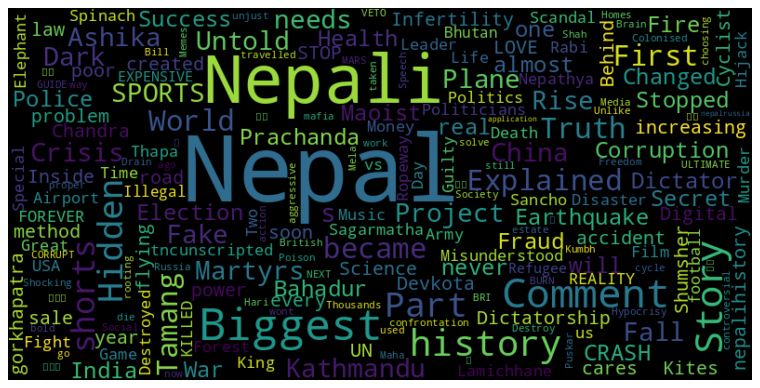

In [40]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

title_text = " ".join(df["Title"])

# Define stopwords
custom_stopwords = {"thenepalicomment", "ft", "ft"}
stopwords = STOPWORDS.union(custom_stopwords)

wordcloud = WordCloud(
    max_font_size=100,
    max_words=200,
    width=800,
    height=400,
    collocations=False,
    stopwords=stopwords,
).generate(title_text)

# Plot the word cloud
plt.figure(figsize=(12, 8), dpi=80)
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


In [43]:
# Building the DFs
most_viewed = df.sort_values("Views", ascending=True)[-20:]
most_viewed["Upload_Date"] = most_viewed["Upload_Date"].dt.strftime("%d %b %Y")

most_liked = df.sort_values("Likes", ascending=True)[-20:]
most_liked["Upload_Date"] = most_liked["Upload_Date"].dt.strftime("%d %b %Y")

most_comments = df.sort_values("Comments", ascending=True)[-20:]
most_comments["Upload_Date"] = most_comments["Upload_Date"].dt.strftime("%d %b %Y")

# Display the charts
most_viewed_bar = px.bar(most_viewed, y="Title", x="Views",
                         title="Most Viewed Videos", hover_data=["Upload_Date"])
most_viewed_bar.update_yaxes(title=None)
most_viewed_bar.update_xaxes(title=None)
most_viewed_bar.show()

most_liked_bar = px.bar(most_liked, y="Title", x="Likes",
                        title="Most Liked Videos", hover_data=["Upload_Date"])
most_liked_bar.update_yaxes(title=None)
most_liked_bar.update_xaxes(title=None)
most_liked_bar.show()

most_comments_bar = px.bar(most_comments, y="Title", x="Comments",
                           title="Highest Comments", hover_data=["Upload_Date"])
most_comments_bar.update_yaxes(title=None)
most_comments_bar.update_xaxes(title=None)
most_comments_bar.show()

In [64]:
# Select the least viewed, least liked, and least commented videos
least_viewed = df.sort_values("Views", ascending=True)[:20]
least_viewed["Upload_Date"] = least_viewed["Upload_Date"].dt.strftime("%d %b %Y")

least_liked = df.sort_values("Likes", ascending=True)[:20]
least_liked["Upload_Date"] = least_liked["Upload_Date"].dt.strftime("%d %b %Y")

least_comments = df.sort_values("Comments", ascending=True)[:20]
least_comments["Upload_Date"] = least_comments["Upload_Date"].dt.strftime("%d %b %Y")

# Display the charts
least_viewed_bar = px.bar(least_viewed, y="Title", x="Views",
                          title="Least Viewed Videos", hover_data=["Upload_Date"])
least_viewed_bar.update_yaxes(title=None)
least_viewed_bar.update_xaxes(title=None)
least_viewed_bar.show()

least_liked_bar = px.bar(least_liked, y="Title", x="Likes",
                         title="Least Liked Videos", hover_data=["Upload_Date"])
least_liked_bar.update_yaxes(title=None)
least_liked_bar.update_xaxes(title=None)
least_liked_bar.show()

least_comments_bar = px.bar(least_comments, y="Title", x="Comments",
                            title="Least Commented Videos", hover_data=["Upload_Date"])
least_comments_bar.update_yaxes(title=None)
least_comments_bar.update_xaxes(title=None)
least_comments_bar.show()


In [67]:
india_mentioned_videos = df[df["Title"].str.contains("india", regex=True, case=False)
| df["Description"].str.contains("India", regex=True, case=False)]
india_mentioned_videos["Tag"] = "India"
# sports_videos[["Title", "Views", "Upload Date"]]

In [68]:
political_videos = df[df["Title"].str.contains("politics", regex=True, case=False)
| df["Description"].str.contains("politics", regex=True, case=False)]
political_videos['Tag'] = 'Politics'

In [69]:
historical_videos = df[df["Title"].str.contains("history", regex=True, case=False)
| df["Description"].str.contains("history", regex=True, case=False)]
historical_videos['Tag'] = 'History'

In [70]:
cat_compare = pd.concat([india_mentioned_videos, political_videos, historical_videos])

category_chart = px.box(cat_compare, x="Tag", y="Views",
                        title="Distibution of Views for Specific Categories")
category_chart.update_xaxes(title="Category")
category_chart.show()

In [71]:
df["VLR"] = df["Likes"] / df["Views"] * 100

In [73]:
vlr_distribution = px.histogram(df, x="VLR", title="Most Videos Have a VLR of 2 to 4", nbins=15, text_auto=True)
vlr_distribution.update_yaxes(title="Count")
vlr_distribution.update_layout(
    xaxis = dict(
        tickmode = 'linear',
        tick0 = 3,
        dtick = 0.5
    )
)
vlr_distribution.update_xaxes(
    title="VLR (%)",
    showgrid=True,
    ticks="outside",
    tickson="boundaries",
    ticklen=20
)

vlr_distribution.show()

In [74]:
highest_vlr = df[["Title", "Views", "Upload_Date", "VLR"]].sort_values("VLR", ascending=False)
highest_vlr[:10]

,Title,Views,Upload_Date,VLR
2,An unjust law is no law at all,11054,2025-02-05,18.056812
0,सरकारको आलोचना गर्नु अपराध होइन | Digital Dict...,5381,2025-02-07,15.517562
1,Freedom Of Speech is not for sale,7952,2025-02-06,11.707746
106,Why is SUIC*DE increasing in Nepal?,106507,2023-06-13,9.451022
29,Why Nepali stopped flying Kites in Sky,11822,2024-10-06,8.704111
110,How is Nepali Kagaj Made? #nepal #nepalipaper ...,69735,2023-06-01,8.236897
3,Digital Dictatorship | Social Media Bill EXPLA...,96827,2025-02-04,8.119636
138,The Success Story of Sancho #shorts #sancho #h...,157616,2022-11-17,7.957948
102,How Nepal grew it's Forest Back,61531,2023-06-22,7.908209
123,How Nepal doubled its TIGER Population,523176,2023-03-03,7.384131
